In [1]:
%load_ext autoreload
%autoreload 2
import os
import glob
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import wandb
import h5py
import sys

sys.path.append('../../../src/benchmark/')
sys.path.append('../../../src/utils/')

from train_functions import train_epochs
from build_model import resnet50_
from utils import viz_dataloader, hdf5_dataset, split_train_valid, list_to_dict, viz_h5_structure
from prediction_analysis import confusion_matrix, plot_cm
from style import set_style

set_style('printing')
plt.rcParams['xtick.top'] = False
plt.rcParams['xtick.bottom'] = False
plt.rcParams['ytick.left'] = False
plt.rcParams['ytick.right'] = False

printing set for seaborn


In [2]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

# imagenet
imagenet_ds = hdf5_dataset('../../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset_transform.h5', folder='imagenet', transform=transforms.ToTensor(),
                           data_key='phase_spectrum', label_key='labels')
train_ds, valid_ds = split_train_valid(imagenet_ds, train_ratio=0.8, seed=42)

train_dl = DataLoader(train_ds, batch_size=600, shuffle=True, num_workers=4)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - train', show_colorbar=True)

valid_dl = DataLoader(valid_ds, batch_size=600, shuffle=False, num_workers=4)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid', show_colorbar=True)

# atom
cv_atom_ds = hdf5_dataset('../../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset_transform.h5', folder='atom', transform=transforms.ToTensor(),
                       data_key='phase_spectrum', label_key='labels')
cv_atom_dl = DataLoader(cv_atom_ds, batch_size=600, shuffle=False, num_workers=4)
viz_dataloader(cv_atom_dl, label_converter=label_converter, title='atom - test', show_colorbar=True)

# noise
cv_noise_ds = hdf5_dataset('../../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset_transform.h5', folder='noise', transform=transforms.ToTensor(),
                       data_key='phase_spectrum', label_key='labels')
cv_noise_dl = DataLoader(cv_noise_ds, batch_size=600, shuffle=False, num_workers=4)
viz_dataloader(cv_noise_dl, label_converter=label_converter, title='noise - test', show_colorbar=True)

In [ ]:
model = resnet50_(in_channels=3, n_classes=17)
outputs = model(torch.randn(2,3,256,256))
print(outputs.shape)

torch.Size([2, 17])


## train

In [ ]:
config = {
    'dataset': '10 million datasets - 100k subset',
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = 'preprocess-fft_phase_spectrum'

In [ ]:
wandb.login()

proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, save_code=True, config=config, group='preprocess')
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [ ]:
device = torch.device('cuda:6')
lr = 1e-3
start = 0
epochs = 200

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, cv_atom_dl, epochs=epochs, start=start, 
                       scheduler=scheduler, model_dir=f'../../../saved_models/{NAME}/', tracking=True)

Epoch: 1/200


  0%|          | 0/134 [00:00<?, ?it/s]

  0%|          | 0/134 [00:05<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.34 GiB. GPU 9 has a total capacty of 79.15 GiB of which 682.62 MiB is free. Process 1962308 has 77.43 GiB memory in use. Including non-PyTorch memory, this process has 1.03 GiB memory in use. Of the allocated memory 544.09 MiB is allocated by PyTorch, and 23.91 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

## analysis

### generate confusion matrix

In [ ]:
model = resnet50_(in_channels=3, n_classes=17)
outputs = model(torch.randn(2,3,256,256))
print(outputs.shape)

model = torch.load('../../../saved_models/preprocess-fft_phase_spectrum/epoch-50.pt')

NAME = 'preprocess-fft_phase_spectrum'
device = torch.device('cuda:6')                

torch.Size([2, 17])


In [ ]:
cm = confusion_matrix(model, train_dl, symmetry_classes, device, n_batches='all')
np.save(f'../../../saved_results/data_preprocessing/FFT_Radon_transform/{NAME}-train_cm.npy', cm)

cm = confusion_matrix(model, valid_dl, symmetry_classes, device, n_batches='all')
np.save(f'../../../saved_results/data_preprocessing/FFT_Radon_transform/{NAME}-valid_cm.npy', cm)

cm = confusion_matrix(model, cv_atom_dl, symmetry_classes, device, n_batches='all')
np.save(f'../../../saved_results/data_preprocessing/FFT_Radon_transform/{NAME}-cv_atom_cm.npy', cm)

cm = confusion_matrix(model, cv_noise_dl, symmetry_classes, device, n_batches='all')
np.save(f'../../../saved_results/data_preprocessing/FFT_Radon_transform/{NAME}-cv_noise_cm.npy', cm)

  0%|          | 0/134 [00:00<?, ?it/s]

100%|██████████| 134/134 [00:53<00:00,  2.51it/s]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,4738.0,4752.0,4717.0,4721.0,4686.0,4767.0,4698.0,4611.0,4717.0,4723.0,4582.0,4734.0,4719.0,4655.0,4771.0,4622.0,4787.0


Accuracy for these batches: 99.99375%


...

Accuracy for these batches: 8.769%


100%|██████████| 170/170 [04:51<00:00,  1.71s/it]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0


Accuracy for these batches: 32.759803921568626%


### visualize confusion matrix

['../../../saved_results/data_preprocessing/FFT_Radon_transform/preprocess-fft_phase_spectrum-train_cm.npy', '../../../saved_results/data_preprocessing/FFT_Radon_transform/preprocess-fft_phase_spectrum-valid_cm.npy', '../../../saved_results/data_preprocessing/FFT_Radon_transform/preprocess-fft_phase_spectrum-cv_atom_cm.npy', '../../../saved_results/data_preprocessing/FFT_Radon_transform/preprocess-fft_phase_spectrum-cv_noise_cm.npy', '../../../saved_results/data_preprocessing/FFT_Radon_transform/preprocess-fft_phase_spectrum-test_cm.npy']
Summary_cm-preprocess-fft_phase_spectrum-train_cm


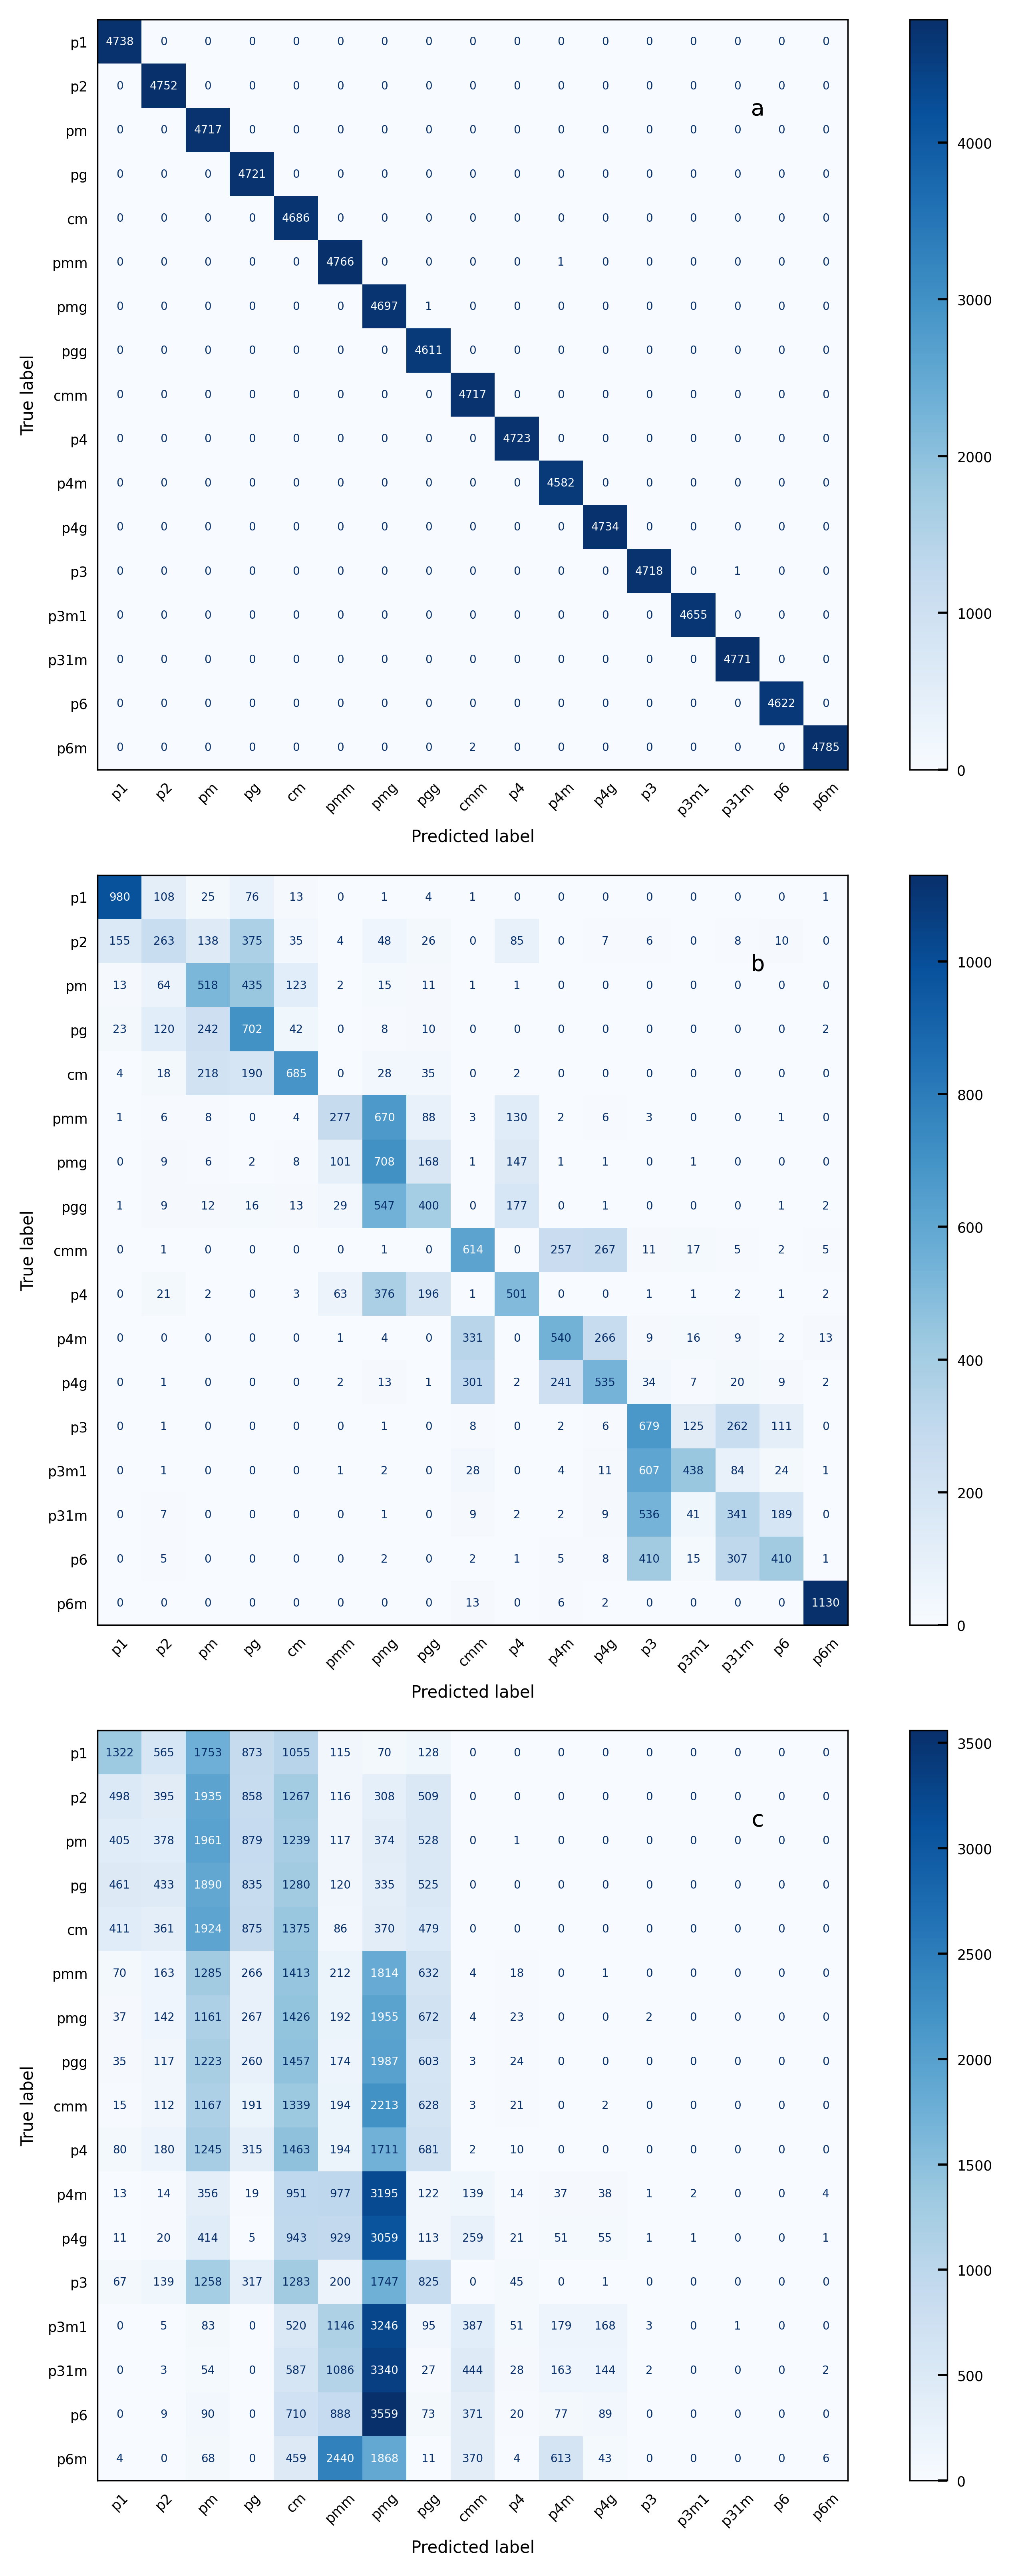

In [ ]:
order = ['train', 'valid', 'cv_atom', 'cv_noise']
def sort_key(file_path):
    for index, key in enumerate(order):
        if key in file_path:
            return index
    return len(order)

files = glob.glob(f'../../../saved_results/data_preprocessing/FFT_Radon_transform/*phase*')
sorted_files = sorted(files, key=sort_key)
print(sorted_files)
NAME = 'Summary_cm-' + os.path.basename(sorted_files[0]).split('.')[0]
print(NAME)

fig, axes = plt.subplots(3, 1, figsize=(6.5, 13))
for i, (ax, file) in enumerate(zip(axes, sorted_files)):
    cm = np.load(file)
    plot_cm(cm, symmetry_classes, title=None, ax=ax, cm_style='simple', fig_style='printing', fig_index=i, font_size=4)
plt.tight_layout()
plt.savefig(f'../../../figures/data_preprocessing/FFT_Radon_transform/{NAME}.png')
plt.savefig(f'../../../figures/data_preprocessing/FFT_Radon_transform/{NAME}.svg')
plt.show()